# Experimental Graph Playground

This notebook hosts an experimental graph that can be called from the router playground.

Current behavior:
- validates uploaded file input (PDF/PNG/JPEG/WebP, max 10MB)
- calls the existing Knowledge service `/documents/expense-draft` extraction endpoint
- for supplier invoices with extracted item lines, creates a Business `/inventory/import-previews` draft
- after user approval, confirms the inventory import, re-reads the created/matched inventory items from Mongo through Business APIs, and creates an `invoice_import_review` draft with `inventory_item_id` links
- for supplier invoices without extracted item lines, creates an `invoice_import_review` draft node
- returns `expense_inventory_intake` with both the expense draft and inventory import preview for user approval
- returns `invoice_import_review` when an invoice needs expense approval or has inventory lines ready to link by Mongo id


In [8]:
from __future__ import annotations

import asyncio
import mimetypes
from decimal import Decimal, InvalidOperation
from pathlib import Path
from typing import Any, Literal, TypedDict

import httpx
from langgraph.graph import END, StateGraph

SUPPORTED_UPLOAD_MIME_TYPES = {
    "application/pdf",
    "image/png",
    "image/jpeg",
    "image/webp",
}
MAX_UPLOAD_BYTES = 10 * 1024 * 1024

ResponseType = Literal[
    "expense",
    "expense_inventory_intake",
    "invoice_import_review",
    "inventory_intake",
    "document_review",
]


class ExperimentalGraphState(TypedDict, total=False):
    message: str
    history: list[Any]
    stream: bool
    user_id: str
    company_id: str
    knowledge_url: str
    business_url: str
    source_document_type: Literal["auto", "invoice", "receipt"]
    filename: str
    file_content_type: str
    file_bytes: bytes
    validated_upload: dict[str, Any]
    extraction_payload: dict[str, Any]
    approved_inventory_import_preview_id: str
    inventory_import_preview: dict[str, Any]
    inventory_import_result: dict[str, Any]
    confirmed_inventory_lines: list[dict[str, Any]]
    inventory_import_error: str
    invoice_import_review: dict[str, Any]
    response_type: ResponseType
    response_payload: dict[str, Any]
    answer: str
    tokens: list[str]
    usage_events: list[dict[str, Any]]


def _classify_response_type(extraction_payload: dict[str, Any]) -> ResponseType:
    """Choose a flexible output envelope type from extracted content."""
    draft = extraction_payload.get("draft") if isinstance(extraction_payload, dict) else None
    extracted_text = extraction_payload.get("extracted_text") if isinstance(extraction_payload, dict) else None

    source_document_type = ""
    if isinstance(draft, dict):
        source_document_type = str(draft.get("source_document_type") or "").strip().lower()

    text = str(extracted_text or "").lower()

    expense_markers = {
        "invoice",
        "receipt",
        "vat",
        "subtotal",
        "total",
        "supplier",
        "counterparty",
    }
    inventory_markers = {
        "inventory",
        "stock",
        "warehouse",
        "sku",
        "quantity",
        "location",
    }

    if source_document_type in {"invoice", "receipt"}:
        return "expense"

    if any(marker in text for marker in expense_markers):
        return "expense"

    if any(marker in text for marker in inventory_markers):
        return "inventory_intake"

    return "document_review"


def _is_invoice_document(extraction_payload: dict[str, Any]) -> bool:
    draft = extraction_payload.get("draft") if isinstance(extraction_payload, dict) else None
    if not isinstance(draft, dict):
        return False

    source_document_type = str(draft.get("source_document_type") or "").strip().lower()
    return source_document_type == "invoice"


def _has_invoice_items(extraction_payload: dict[str, Any]) -> bool:
    if not _is_invoice_document(extraction_payload):
        return False

    draft = extraction_payload.get("draft")
    if not isinstance(draft, dict):
        return False

    items = draft.get("items")
    return isinstance(items, list) and len(items) > 0


def _route_start(
    state: ExperimentalGraphState,
) -> Literal["confirm_inventory_import_preview", "validate_upload"]:
    if state.get("approved_inventory_import_preview_id"):
        return "confirm_inventory_import_preview"
    return "validate_upload"


def _route_after_extraction(
    state: ExperimentalGraphState,
) -> Literal["create_inventory_import_preview", "create_invoice_import_review", "route_response"]:
    payload = state["extraction_payload"]
    if _has_invoice_items(payload):
        return "create_inventory_import_preview"
    if _is_invoice_document(payload):
        return "create_invoice_import_review"
    return "route_response"


def _to_decimal(value: Any) -> Decimal | None:
    try:
        return Decimal(str(value))
    except (InvalidOperation, TypeError, ValueError):
        return None


def _to_positive_decimal(value: Any) -> Decimal | None:
    amount = _to_decimal(value)
    return amount if amount is not None and amount > 0 else None


def _to_nonnegative_decimal(value: Any) -> Decimal | None:
    amount = _to_decimal(value)
    return amount if amount is not None and amount >= 0 else None


def _optional_string(value: Any) -> str | None:
    if value is None:
        return None
    text = str(value).strip()
    return text or None


def _build_inventory_candidates(draft: dict[str, Any]) -> list[dict[str, Any]]:
    candidates: list[dict[str, Any]] = []

    for item in draft.get("items") or []:
        if not isinstance(item, dict):
            continue

        description = str(item.get("description") or "").strip()
        quantity = _to_positive_decimal(item.get("quantity"))
        if not description or quantity is None:
            continue

        unit_price = item.get("unit_price")
        unit_price_decimal = _to_nonnegative_decimal(unit_price) if unit_price is not None else None
        unit = _optional_string(item.get("unit_label")) or "pcs"

        candidates.append(
            {
                "description": description,
                "sku": _optional_string(item.get("sku")),
                "barcode": _optional_string(item.get("barcode")),
                "quantity": str(quantity),
                "unit": unit,
                "unit_price": str(unit_price_decimal) if unit_price_decimal is not None else None,
            }
        )

    return candidates


def _candidate_from_preview_line(line: dict[str, Any]) -> dict[str, Any]:
    candidate = line.get("candidate") if isinstance(line, dict) else None
    return candidate if isinstance(candidate, dict) else {}


def _first_item(payload: dict[str, Any]) -> dict[str, Any] | None:
    items = payload.get("items")
    if isinstance(items, list) and items and isinstance(items[0], dict):
        return items[0]
    return None


def _invoice_item_from_inventory_line(line: dict[str, Any]) -> dict[str, Any] | None:
    item = line.get("item")
    if not isinstance(item, dict):
        return None

    candidate = _candidate_from_preview_line(line)
    quantity = _to_positive_decimal(line.get("receipt_quantity") or candidate.get("quantity"))
    unit_price = _to_nonnegative_decimal(candidate.get("unit_price"))
    if unit_price is None:
        unit_price = _to_nonnegative_decimal(item.get("selling_price")) or Decimal("0")

    return {
        "description": item.get("name") or candidate.get("description") or "Inventory item",
        "quantity": str(quantity or Decimal("1")),
        "unit_label": item.get("unit") or candidate.get("unit") or "pcs",
        "unit_price": str(unit_price),
        "vat_rate": "0.20",
        "category": item.get("category"),
        "inventory_item_id": item.get("id"),
        "inventory_location_id": line.get("location_id"),
        "stock_quantity": str(quantity or Decimal("1")),
    }


def _build_invoice_import_review_from_inventory(
    *,
    preview: dict[str, Any],
    inventory_lines: list[dict[str, Any]],
    extraction_payload: dict[str, Any] | None = None,
) -> dict[str, Any]:
    source_payload = extraction_payload or {}
    source_draft = source_payload.get("draft") if isinstance(source_payload, dict) else None
    draft = dict(source_draft) if isinstance(source_draft, dict) else {}
    items = [item for line in inventory_lines if (item := _invoice_item_from_inventory_line(line)) is not None]

    draft.update(
        {
            "company_id": preview.get("company_id"),
            "items": items,
            "status": draft.get("status") or "draft",
            "currency": draft.get("currency") or "EUR",
            "notes": draft.get("notes")
            or f"Created from confirmed inventory import preview {preview.get('id')}.",
        }
    )

    return {
        "type": "invoice_import_review",
        "draft": draft,
        "document": source_payload.get("document") if isinstance(source_payload, dict) else None,
        "provider": source_payload.get("provider") if isinstance(source_payload, dict) else None,
        "model": source_payload.get("model") if isinstance(source_payload, dict) else None,
        "extracted_at": source_payload.get("extracted_at") if isinstance(source_payload, dict) else None,
        "extracted_text": source_payload.get("extracted_text") if isinstance(source_payload, dict) else None,
        "inventory_import_preview": preview,
        "inventory_lines": inventory_lines,
        "approval_action": {
            "method": "POST",
            "path": "/invoices",
            "note": (
                "Render this invoice draft for user approval. Lines include inventory_item_id "
                "and inventory_location_id from Mongo so confirmed invoices can issue stock."
            ),
        },
    }


async def _fetch_inventory_item_by_id(
    client: httpx.AsyncClient,
    *,
    business_url: str,
    user_id: str,
    company_id: str,
    item_id: str,
) -> dict[str, Any] | None:
    response = await client.get(
        f"{business_url}/inventory/items/{item_id}",
        headers={"x-user-id": user_id},
        params={"company_id": company_id},
    )
    if response.status_code == 404:
        return None
    response.raise_for_status()
    item = response.json()
    return item if isinstance(item, dict) else None


async def _find_inventory_item_by_identifier(
    client: httpx.AsyncClient,
    *,
    business_url: str,
    user_id: str,
    company_id: str,
    key: Literal["sku", "barcode"],
    value: str | None,
) -> dict[str, Any] | None:
    if not value:
        return None
    response = await client.get(
        f"{business_url}/inventory/items",
        headers={"x-user-id": user_id},
        params={"company_id": company_id, key: value, "limit": 1},
    )
    response.raise_for_status()
    payload = response.json()
    return _first_item(payload) if isinstance(payload, dict) else None


async def _search_inventory_item(
    client: httpx.AsyncClient,
    *,
    business_url: str,
    user_id: str,
    company_id: str,
    query: str | None,
) -> dict[str, Any] | None:
    if not query:
        return None
    response = await client.post(
        f"{business_url}/inventory/search",
        headers={"x-user-id": user_id},
        json={"company_id": company_id, "query": query, "include_stock": False, "limit": 1},
    )
    response.raise_for_status()
    payload = response.json()
    matches = payload.get("matches") if isinstance(payload, dict) else None
    if not isinstance(matches, list) or not matches:
        return None
    match = matches[0]
    if not isinstance(match, dict):
        return None
    item_id = match.get("item_id")
    if not item_id:
        return None
    return await _fetch_inventory_item_by_id(
        client,
        business_url=business_url,
        user_id=user_id,
        company_id=company_id,
        item_id=item_id,
    )


async def _resolve_inventory_item_for_confirmed_line(
    client: httpx.AsyncClient,
    *,
    business_url: str,
    user_id: str,
    company_id: str,
    line: dict[str, Any],
) -> dict[str, Any] | None:
    candidate = _candidate_from_preview_line(line)
    matched_item_id = _optional_string(line.get("matched_item_id"))
    if matched_item_id:
        item = await _fetch_inventory_item_by_id(
            client,
            business_url=business_url,
            user_id=user_id,
            company_id=company_id,
            item_id=matched_item_id,
        )
        if item:
            return item

    for key in ("sku", "barcode"):
        item = await _find_inventory_item_by_identifier(
            client,
            business_url=business_url,
            user_id=user_id,
            company_id=company_id,
            key=key,
            value=_optional_string(candidate.get(key)),
        )
        if item:
            return item

    return await _search_inventory_item(
        client,
        business_url=business_url,
        user_id=user_id,
        company_id=company_id,
        query=_optional_string(candidate.get("description")),
    )


async def _resolve_confirmed_inventory_lines(
    client: httpx.AsyncClient,
    *,
    business_url: str,
    user_id: str,
    company_id: str,
    preview: dict[str, Any],
) -> list[dict[str, Any]]:
    resolved: list[dict[str, Any]] = []
    for index, line in enumerate(preview.get("lines") or []):
        if not isinstance(line, dict):
            continue
        item = await _resolve_inventory_item_for_confirmed_line(
            client,
            business_url=business_url,
            user_id=user_id,
            company_id=company_id,
            line=line,
        )
        if item is None:
            continue
        resolved.append({**line, "line_index": index, "item": item})
    return resolved


def build_experimental_graph():
    async def route_start_node(state: ExperimentalGraphState) -> ExperimentalGraphState:
        await asyncio.sleep(0)
        return {}

    async def validate_upload_node(state: ExperimentalGraphState) -> ExperimentalGraphState:
        await asyncio.sleep(0)
        file_bytes = state.get("file_bytes") or b""
        filename = (state.get("filename") or "upload").strip()
        content_type = (state.get("file_content_type") or "").strip().lower()

        if not file_bytes:
            raise ValueError("No file bytes were provided.")

        if not content_type:
            guessed_content_type, _ = mimetypes.guess_type(filename)
            content_type = (guessed_content_type or "application/octet-stream").lower()

        if content_type not in SUPPORTED_UPLOAD_MIME_TYPES:
            raise ValueError(
                "Unsupported file type. Allowed: PDF, PNG, JPEG, WEBP "
                f"(received: {content_type})."
            )

        if len(file_bytes) > MAX_UPLOAD_BYTES:
            raise ValueError(
                f"File is too large ({len(file_bytes)} bytes). Max allowed is {MAX_UPLOAD_BYTES} bytes."
            )

        print(
            "[experimental/validate]"
            f" filename={filename}"
            f" content_type={content_type}"
            f" bytes={len(file_bytes)}"
        )

        return {
            "validated_upload": {
                "filename": filename,
                "content_type": content_type,
                "size_bytes": len(file_bytes),
            },
            "filename": filename,
            "file_content_type": content_type,
        }

    async def extract_with_knowledge_node(state: ExperimentalGraphState) -> ExperimentalGraphState:
        knowledge_url = (state.get("knowledge_url") or "http://localhost:8003").rstrip("/")
        user_id = (state.get("user_id") or "experimental-user").strip()
        company_id = (state.get("company_id") or "").strip()
        if not company_id:
            raise ValueError("company_id is required for knowledge-service extraction.")

        filename = state["filename"]
        content_type = state["file_content_type"]
        file_bytes = state["file_bytes"]
        source_document_type = state.get("source_document_type") or "auto"

        files = {
            "file": (filename, file_bytes, content_type),
        }
        data = {
            "company_id": company_id,
            "source_document_type": source_document_type,
        }

        async with httpx.AsyncClient(timeout=45.0) as client:
            response = await client.post(
                f"{knowledge_url}/documents/expense-draft",
                headers={"x-user-id": user_id},
                files=files,
                data=data,
            )
            response.raise_for_status()
            payload = response.json()

        print(
            "[experimental/knowledge]"
            f" provider={payload.get('provider')}"
            f" model={payload.get('model')}"
        )

        return {
            "extraction_payload": payload,
        }

    async def create_inventory_import_preview_node(state: ExperimentalGraphState) -> ExperimentalGraphState:
        await asyncio.sleep(0)
        payload = state["extraction_payload"]
        if not _has_invoice_items(payload):
            return {}

        draft = payload.get("draft")
        if not isinstance(draft, dict):
            return {}

        lines = _build_inventory_candidates(draft)
        if not lines:
            return {
                "inventory_import_error": "No valid inventory item lines were extracted from the invoice."
            }

        business_url = (state.get("business_url") or "http://localhost:8005").rstrip("/")
        user_id = (state.get("user_id") or "experimental-user").strip()
        company_id = (state.get("company_id") or "").strip()
        document = payload.get("document") if isinstance(payload, dict) else None
        document_id = document.get("id") if isinstance(document, dict) else None

        body = {
            "company_id": company_id,
            "document_id": document_id,
            "source_type": "supplier_invoice_upload",
            "lines": lines,
        }

        try:
            async with httpx.AsyncClient(timeout=45.0) as client:
                response = await client.post(
                    f"{business_url}/inventory/import-previews",
                    headers={"x-user-id": user_id},
                    json=body,
                )
                response.raise_for_status()
                preview = response.json()
        except httpx.HTTPStatusError as exc:
            return {
                "inventory_import_error": (
                    "Business service rejected the inventory import preview "
                    f"({exc.response.status_code}): {exc.response.text}"
                )
            }
        except httpx.HTTPError as exc:
            return {
                "inventory_import_error": (
                    "Business service is unavailable for inventory import preview creation "
                    f"({exc.__class__.__name__}: {exc})."
                )
            }

        print(
            "[experimental/inventory-preview]"
            f" preview_id={preview.get('id')}"
            f" lines={len(preview.get('lines') or [])}"
        )

        return {
            "inventory_import_preview": preview,
        }

    async def confirm_inventory_import_preview_node(state: ExperimentalGraphState) -> ExperimentalGraphState:
        preview_id = (state.get("approved_inventory_import_preview_id") or "").strip()
        if not preview_id:
            return {}

        business_url = (state.get("business_url") or "http://localhost:8005").rstrip("/")
        user_id = (state.get("user_id") or "experimental-user").strip()
        company_id = (state.get("company_id") or "").strip()
        if not company_id:
            raise ValueError("company_id is required to confirm an inventory import preview.")

        try:
            async with httpx.AsyncClient(timeout=45.0) as client:
                try:
                    confirm_response = await client.post(
                        f"{business_url}/inventory/import-previews/{preview_id}/confirm",
                        headers={"x-user-id": user_id},
                    )
                    confirm_response.raise_for_status()
                    import_result = confirm_response.json()
                except httpx.HTTPStatusError as exc:
                    already_confirmed = (
                        exc.response.status_code == 400
                        and "Only draft previews can be confirmed" in exc.response.text
                    )
                    if not already_confirmed:
                        raise
                    import_result = {"preview_id": preview_id, "already_confirmed": True}

                preview_response = await client.get(
                    f"{business_url}/inventory/import-previews/{preview_id}",
                    headers={"x-user-id": user_id},
                )
                preview_response.raise_for_status()
                preview = preview_response.json()
                if isinstance(preview, dict) and preview.get("status") != "confirmed":
                    return {
                        "inventory_import_error": (
                            "Inventory import preview must be confirmed before creating "
                            f"invoice review links (current status: {preview.get('status')})."
                        )
                    }
                inventory_lines = await _resolve_confirmed_inventory_lines(
                    client,
                    business_url=business_url,
                    user_id=user_id,
                    company_id=company_id,
                    preview=preview,
                )
        except httpx.HTTPStatusError as exc:
            return {
                "inventory_import_error": (
                    "Business service rejected inventory import approval handling "
                    f"({exc.response.status_code}): {exc.response.text}"
                )
            }
        except httpx.HTTPError as exc:
            return {
                "inventory_import_error": (
                    "Business service is unavailable for inventory import approval handling "
                    f"({exc.__class__.__name__}: {exc})."
                )
            }

        print(
            "[experimental/inventory-approved]"
            f" preview_id={preview_id}"
            f" linked_items={len(inventory_lines)}"
        )

        return {
            "inventory_import_preview": preview,
            "inventory_import_result": import_result,
            "confirmed_inventory_lines": inventory_lines,
        }

    async def create_invoice_import_review_node(state: ExperimentalGraphState) -> ExperimentalGraphState:
        await asyncio.sleep(0)
        confirmed_inventory_lines = state.get("confirmed_inventory_lines")
        if isinstance(confirmed_inventory_lines, list) and confirmed_inventory_lines:
            preview = state.get("inventory_import_preview") or {}
            review = _build_invoice_import_review_from_inventory(
                preview=preview,
                inventory_lines=confirmed_inventory_lines,
                extraction_payload=state.get("extraction_payload"),
            )
            print(
                "[experimental/invoice-review-from-inventory]"
                f" preview_id={preview.get('id')}"
                f" linked_items={len(review.get('draft', {}).get('items') or [])}"
            )
            return {"invoice_import_review": review}

        if state.get("approved_inventory_import_preview_id"):
            return {
                "inventory_import_error": (
                    "Inventory import was approved, but no confirmed inventory items could be resolved from DB."
                )
            }

        payload = state.get("extraction_payload") or {}
        if not _is_invoice_document(payload) or _has_invoice_items(payload):
            return {}

        review = {
            "type": "invoice_import_review",
            "draft": payload.get("draft"),
            "document": payload.get("document"),
            "provider": payload.get("provider"),
            "model": payload.get("model"),
            "extracted_at": payload.get("extracted_at"),
            "extracted_text": payload.get("extracted_text"),
            "approval_action": {
                "method": "POST",
                "path": None,
                "note": (
                    "Render this invoice/expense draft for user approval. "
                    "After approval, submit it through the caller's expense confirmation flow."
                ),
            },
        }

        print(
            "[experimental/invoice-review]"
            f" document_id={(payload.get('document') or {}).get('id') if isinstance(payload.get('document'), dict) else None}"
        )

        return {
            "invoice_import_review": review,
        }

    async def route_response_node(state: ExperimentalGraphState) -> ExperimentalGraphState:
        await asyncio.sleep(0)
        payload = state.get("extraction_payload") or {}
        response_type = _classify_response_type(payload)
        inventory_import_preview = state.get("inventory_import_preview")
        inventory_import_error = state.get("inventory_import_error")
        invoice_import_review = state.get("invoice_import_review")

        if isinstance(invoice_import_review, dict):
            response_type = "invoice_import_review"
            response_payload = invoice_import_review
        elif response_type == "expense" and isinstance(inventory_import_preview, dict):
            preview_id = inventory_import_preview.get("id")
            response_type = "expense_inventory_intake"
            response_payload = {
                "type": "expense_inventory_intake",
                "draft": payload.get("draft"),
                "document": payload.get("document"),
                "provider": payload.get("provider"),
                "model": payload.get("model"),
                "extracted_at": payload.get("extracted_at"),
                "extracted_text": payload.get("extracted_text"),
                "inventory_import_preview": inventory_import_preview,
                "approval_action": {
                    "method": "POST",
                    "path": f"/inventory/import-previews/{preview_id}/confirm" if preview_id else None,
                    "note": "Render the preview lines for user approval before confirming.",
                },
            }
        elif response_type == "expense":
            response_payload = {
                "type": "expense",
                "draft": payload.get("draft"),
                "document": payload.get("document"),
                "provider": payload.get("provider"),
                "model": payload.get("model"),
                "extracted_at": payload.get("extracted_at"),
                "extracted_text": payload.get("extracted_text"),
                "inventory_import_error": inventory_import_error,
            }
        elif response_type == "inventory_intake":
            response_payload = {
                "type": "inventory_intake",
                "note": "Inventory-like content detected. Add inventory extraction endpoint to continue.",
                "document": payload.get("document"),
                "extracted_text": payload.get("extracted_text"),
            }
        else:
            response_payload = {
                "type": "document_review",
                "note": "Document content is ambiguous. Manual review or dedicated parser is needed.",
                "document": payload.get("document"),
                "extracted_text": payload.get("extracted_text"),
            }

        if response_type == "expense_inventory_intake":
            answer = (
                "[experimental] invoice items were extracted and converted to an inventory "
                "import preview. Render the preview form for user approval before confirming."
            )
        elif response_type == "invoice_import_review":
            if state.get("confirmed_inventory_lines"):
                answer = (
                    "[experimental] inventory import was approved and converted to an invoice "
                    "import review draft with inventory_item_id links."
                )
            else:
                answer = (
                    "[experimental] invoice has no inventory item lines, so it was converted "
                    "to an invoice import review draft for user approval."
                )
        elif inventory_import_error:
            answer = (
                f"[experimental] handled request and returned type='{response_type}', "
                "but inventory preview handling needs review."
            )
        else:
            answer = f"[experimental] handled upload and returned type='{response_type}'."

        if state.get("stream"):
            print(answer)

        return {
            "response_type": response_type,
            "response_payload": response_payload,
            "inventory_import_preview": inventory_import_preview,
            "inventory_import_error": inventory_import_error,
            "invoice_import_review": invoice_import_review,
            "answer": answer,
            "tokens": [answer],
            "usage_events": [],
        }

    graph = StateGraph(ExperimentalGraphState)
    graph.add_node("route_start", route_start_node)
    graph.add_node("validate_upload", validate_upload_node)
    graph.add_node("extract_with_knowledge", extract_with_knowledge_node)
    graph.add_node("create_inventory_import_preview", create_inventory_import_preview_node)
    graph.add_node("confirm_inventory_import_preview", confirm_inventory_import_preview_node)
    graph.add_node("create_invoice_import_review", create_invoice_import_review_node)
    graph.add_node("route_response", route_response_node)
    graph.set_entry_point("route_start")
    graph.add_conditional_edges(
        "route_start",
        _route_start,
        {
            "validate_upload": "validate_upload",
            "confirm_inventory_import_preview": "confirm_inventory_import_preview",
        },
    )
    graph.add_edge("validate_upload", "extract_with_knowledge")
    graph.add_conditional_edges(
        "extract_with_knowledge",
        _route_after_extraction,
        {
            "create_inventory_import_preview": "create_inventory_import_preview",
            "create_invoice_import_review": "create_invoice_import_review",
            "route_response": "route_response",
        },
    )
    graph.add_edge("create_inventory_import_preview", "route_response")
    graph.add_edge("confirm_inventory_import_preview", "create_invoice_import_review")
    graph.add_edge("create_invoice_import_review", "route_response")
    graph.add_edge("route_response", END)
    return graph.compile()


async def run_experimental_graph_tool(
    *,
    message: str,
    file_bytes: bytes,
    filename: str,
    file_content_type: str,
    company_id: str,
    user_id: str = "experimental-user",
    knowledge_url: str = "http://localhost:8003",
    business_url: str = "http://localhost:8005",
    source_document_type: Literal["auto", "invoice", "receipt"] = "auto",
    history: list[Any] | None = None,
    stream: bool = False,
) -> dict[str, Any]:
    app = build_experimental_graph()
    state: ExperimentalGraphState = {
        "message": message,
        "history": history or [],
        "stream": stream,
        "file_bytes": file_bytes,
        "filename": filename,
        "file_content_type": file_content_type,
        "company_id": company_id,
        "user_id": user_id,
        "knowledge_url": knowledge_url,
        "business_url": business_url,
        "source_document_type": source_document_type,
    }
    final_state = await app.ainvoke(state)
    return {
        "answer": final_state.get("answer", ""),
        "response_type": final_state.get("response_type", "document_review"),
        "response_payload": final_state.get("response_payload", {}),
        "validated_upload": final_state.get("validated_upload", {}),
        "inventory_import_preview": final_state.get("inventory_import_preview"),
        "inventory_import_result": final_state.get("inventory_import_result"),
        "confirmed_inventory_lines": final_state.get("confirmed_inventory_lines", []),
        "inventory_import_error": final_state.get("inventory_import_error"),
        "invoice_import_review": final_state.get("invoice_import_review"),
        "tokens": final_state.get("tokens", []),
        "usage_events": final_state.get("usage_events", []),
    }


async def run_invoice_import_review_after_inventory_import_approval(
    *,
    preview_id: str,
    company_id: str,
    user_id: str = "experimental-user",
    business_url: str = "http://localhost:8005",
    stream: bool = False,
) -> dict[str, Any]:
    app = build_experimental_graph()
    state: ExperimentalGraphState = {
        "message": "Approve inventory import and prepare linked invoice review.",
        "history": [],
        "stream": stream,
        "approved_inventory_import_preview_id": preview_id,
        "company_id": company_id,
        "user_id": user_id,
        "business_url": business_url,
    }
    final_state = await app.ainvoke(state)
    return {
        "answer": final_state.get("answer", ""),
        "response_type": final_state.get("response_type", "document_review"),
        "response_payload": final_state.get("response_payload", {}),
        "inventory_import_preview": final_state.get("inventory_import_preview"),
        "inventory_import_result": final_state.get("inventory_import_result"),
        "confirmed_inventory_lines": final_state.get("confirmed_inventory_lines", []),
        "inventory_import_error": final_state.get("inventory_import_error"),
        "invoice_import_review": final_state.get("invoice_import_review"),
        "tokens": final_state.get("tokens", []),
        "usage_events": final_state.get("usage_events", []),
    }


async def run_experimental_graph_tool_from_path(
    *,
    message: str,
    file_path: str,
    company_id: str,
    user_id: str = "experimental-user",
    knowledge_url: str = "http://localhost:8003",
    business_url: str = "http://localhost:8005",
    source_document_type: Literal["auto", "invoice", "receipt"] = "auto",
    stream: bool = False,
) -> dict[str, Any]:
    path = Path(file_path)
    content_type = (mimetypes.guess_type(path.name)[0] or "application/octet-stream").lower()
    file_bytes = path.read_bytes()
    return await run_experimental_graph_tool(
        message=message,
        file_bytes=file_bytes,
        filename=path.name,
        file_content_type=content_type,
        company_id=company_id,
        user_id=user_id,
        knowledge_url=knowledge_url,
        business_url=business_url,
        source_document_type=source_document_type,
        stream=stream,
    )


print("Experimental graph helpers ready.")


Experimental graph helpers ready.


In [ ]:
# Verification sample for supplier invoices.
# Run after starting Knowledge (8003) and Business (8005), then replace the IDs/path.
#
# result = await run_experimental_graph_tool_from_path(
#     message="Extract this supplier invoice and prepare review drafts.",
#     file_path="/absolute/path/to/supplier-invoice.pdf",
#     company_id="<company-id>",
#     user_id="<user-id>",
#     knowledge_url="http://localhost:8003",
#     business_url="http://localhost:8005",
#     source_document_type="auto",
#     stream=True,
# )
#
# assert result["response_payload"]["type"] in {
#     "expense",
#     "expense_inventory_intake",
#     "invoice_import_review",
#     "inventory_intake",
#     "document_review",
# }
#
# # After the user approves the inventory preview, use its id to build the invoice review
# # with inventory_item_id links from the DB.
# if result["response_payload"]["type"] == "expense_inventory_intake":
#     approved = await run_invoice_import_review_after_inventory_import_approval(
#         preview_id=result["inventory_import_preview"]["id"],
#         company_id="<company-id>",
#         user_id="<user-id>",
#         business_url="http://localhost:8005",
#         stream=True,
#     )
#     assert approved["response_payload"]["type"] == "invoice_import_review"
#     assert all(
#         item.get("inventory_item_id")
#         for item in approved["response_payload"]["draft"].get("items", [])
#     )
#
# result["response_payload"]


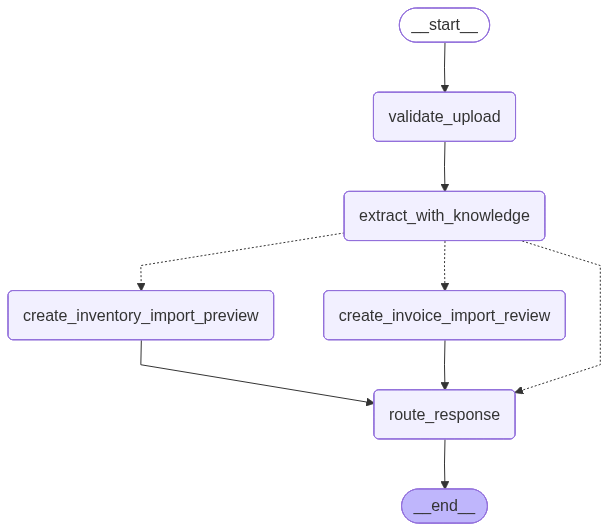

In [9]:
from typing import Any

try:
    from IPython.display import Image, display
except ImportError:
    Image = None
    display = print


def visualize_compiled_experimental_graph(compiled_app: Any, *, label: str = "experimental graph") -> None:
    """Render only the inline graph image."""
    graph = compiled_app.get_graph()

    if Image is None:
        print(f"[{label}] IPython image display is unavailable in this environment.")
        return

    try:
        png_bytes = graph.draw_mermaid_png()
        display(Image(png_bytes))
    except Exception as exc:
        print(f"[{label}] Inline PNG not available ({exc.__class__.__name__}: {exc}).")
        print("Install renderer deps or use graph.draw_mermaid() as fallback.")


builder = globals().get("build_experimental_graph")
if builder is None:
    print("[experimental graph] build_experimental_graph is not defined. Run the helpers cell first.")
else:
    visualize_compiled_experimental_graph(
        builder(),
        label="experimental graph (structural preview)",
    )
